In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv("C:\\Users\\om\\Desktop\\ESM PROJECT\\data\\cleaned_data.csv")

In [2]:
df.head(20)

,Customer_ID,Customer_Name,Quantity,Country,Product_Category,Purchase_Amount,Payment_Method,Transaction_Date
0,1,Ava Hall,63,Mexico,Clothing,780.69,Debit Card,2023-04-14
1,2,Sophia Hall,59,India,Beauty,738.56,PayPal,2023-07-30
2,3,Elijah Thompson,26,France,Books,178.34,Credit Card,2023-09-17
3,4,Elijah White,43,Mexico,Sports,401.09,UPI,2023-06-21
4,5,Ava Harris,48,Germany,Beauty,594.83,Net Banking,2024-10-29
5,6,Elijah Harris,51,India,Toys,966.50,Cash on Delivery,2025-01-18
6,7,Oliver Clark,27,Germany,Home & Kitchen,341.73,Credit Card,2024-03-13
7,8,OLIVIA ALLEN,46,Canada,Home & Kitchen,11.33,Debit Card,2024-01-04
8,9,Liam Harris,54,France,Beauty,279.43,Cash on Delivery,2023-12-06
9,10,Liam Allen,60,Canada,Toys,223.90,Cash on Delivery,2023-08-07


In [3]:
df.shape

(48572, 8)

In [4]:
df.describe()

,Customer_ID,Quantity,Purchase_Amount
count,48572.000000,48572.000000,48572.000000
mean,24990.090896,41.899263,503.228936
std,14429.612771,17.583555,282.344968
min,1.000000,0.000000,5.040000
25%,12497.750000,29.000000,262.665000
50%,24977.500000,43.000000,503.180000
75%,37485.250000,57.000000,743.922500
max,50000.000000,70.000000,999.980000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48572 entries, 0 to 48571
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       48572 non-null  int64  
 1   Customer_Name     48572 non-null  object 
 2   Quantity          48572 non-null  int64  
 3   Country           48572 non-null  object 
 4   Product_Category  48572 non-null  object 
 5   Purchase_Amount   48572 non-null  float64
 6   Payment_Method    48572 non-null  object 
 7   Transaction_Date  48572 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 3.0+ MB


In [6]:
df.isnull().values.any()

np.False_

In [7]:
df.isnull().sum()

Customer_ID         0
Customer_Name       0
Quantity            0
Country             0
Product_Category    0
Purchase_Amount     0
Payment_Method      0
Transaction_Date    0
dtype: int64

In [8]:
df.head(20)

,Customer_ID,Customer_Name,Quantity,Country,Product_Category,Purchase_Amount,Payment_Method,Transaction_Date
0,1,Ava Hall,63,Mexico,Clothing,780.69,Debit Card,2023-04-14
1,2,Sophia Hall,59,India,Beauty,738.56,PayPal,2023-07-30
2,3,Elijah Thompson,26,France,Books,178.34,Credit Card,2023-09-17
3,4,Elijah White,43,Mexico,Sports,401.09,UPI,2023-06-21
4,5,Ava Harris,48,Germany,Beauty,594.83,Net Banking,2024-10-29
5,6,Elijah Harris,51,India,Toys,966.50,Cash on Delivery,2025-01-18
6,7,Oliver Clark,27,Germany,Home & Kitchen,341.73,Credit Card,2024-03-13
7,8,OLIVIA ALLEN,46,Canada,Home & Kitchen,11.33,Debit Card,2024-01-04
8,9,Liam Harris,54,France,Beauty,279.43,Cash on Delivery,2023-12-06
9,10,Liam Allen,60,Canada,Toys,223.90,Cash on Delivery,2023-08-07


In [9]:
#Ensures consistent and clean text data, which improves data analysis accuracy#

text_cols = ['Customer_Name', 'Country', 'Product_Category', 'Payment_Method']

for col in text_cols:
    df[col] = df[col].str.strip().str.title()

In [10]:
#The function identifies abnormal values by comparing data against a statistically defined normal range using IQR#

def detect_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    return outliers, lower_bound, upper_bound

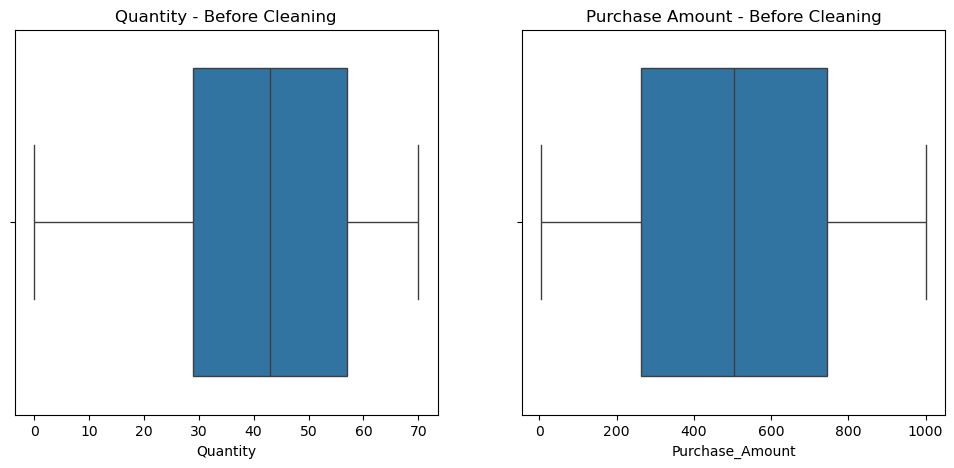

In [11]:
#Boxplots help identify unusual values (outliers) and understand data distribution before cleaning#

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['Quantity'])
plt.title('Quantity - Before Cleaning')

plt.subplot(1,2,2)
sns.boxplot(x=df['Purchase_Amount'])
plt.title('Purchase Amount - Before Cleaning')

plt.show()

In [12]:
# Quantity
qty_outliers, q_low, q_high = detect_outliers('Quantity')
print("Quantity Outliers Count:", len(qty_outliers))

# Purchase Amount
amt_outliers, a_low, a_high = detect_outliers('Purchase_Amount')
print("Purchase Amount Outliers Count:", len(amt_outliers))

Quantity Outliers Count: 0
Purchase Amount Outliers Count: 0


In [13]:
#Shows unusual quantity values (too high or too low)#

print(qty_outliers)

#Shows unusual transaction amounts#

print(amt_outliers)

Empty DataFrame
Columns: [Customer_ID, Customer_Name, Quantity, Country, Product_Category, Purchase_Amount, Payment_Method, Transaction_Date]
Index: []
Empty DataFrame
Columns: [Customer_ID, Customer_Name, Quantity, Country, Product_Category, Purchase_Amount, Payment_Method, Transaction_Date]
Index: []


In [14]:
#Total revenue shows the complete earnings of the business#

print("Total Revenue:", df['Purchase_Amount'].sum())

Total Revenue: 24442835.89


Product_Category
Toys              3750927.08
Books             2998328.51
Sports            2995853.57
Clothing          2988587.55
Electronics       2946854.99
Grocery           2943223.64
Home & Kitchen    2942017.20
Beauty            2877043.35
Name: Purchase_Amount, dtype: float64


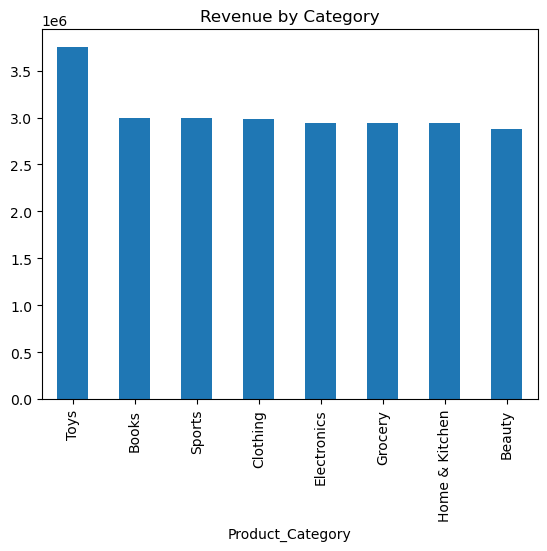

In [ ]:
#This graph shows which product categories earn the most and least revenue#

Revenuebycat=df.groupby(
    'Product_Category')[
        'Purchase_Amount'
        ].sum().sort_values(ascending=False)
print(Revenuebycat)
Revenuebycat.plot(kind='bar')
plt.title('Revenue by Category')
plt.show()

Country
Mexico       3108255.43
Canada       2395214.01
Usa          2392639.24
Australia    2388893.30
France       2387855.81
Germany      2371213.38
Brazil       2369822.85
Japan        2354036.59
India        2351919.02
Uk           2322986.26
Name: Purchase_Amount, dtype: float64


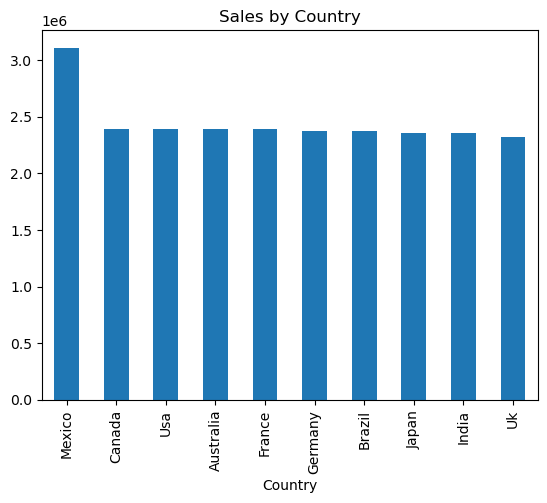

In [16]:
#This chart shows which countries generate the most and least sales#

SalesbyCountry=df.groupby('Country')['Purchase_Amount'].sum().sort_values(ascending=False)
print(SalesbyCountry)
SalesbyCountry.plot(kind='bar')
plt.title('Sales by Country')
plt.show()

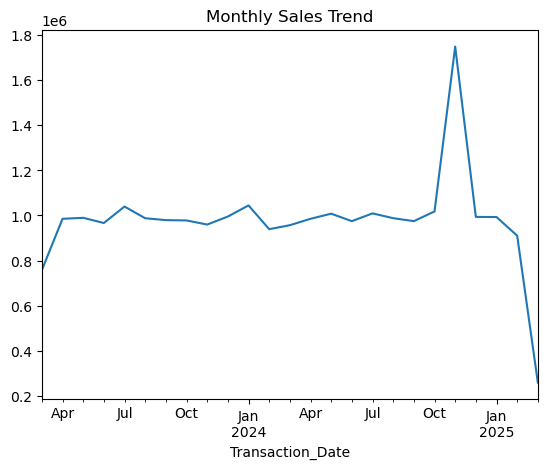

In [17]:
#This graph shows how sales change every month (increase or decrease)#

df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])

monthly = df.groupby(df['Transaction_Date'].dt.to_period('M'))['Purchase_Amount'].sum()

monthly.plot(kind='line')
plt.title('Monthly Sales Trend')
plt.show()

In [23]:
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])

# Create Year-Month column
df['YearMonth'] = df['Transaction_Date'].dt.to_period('M')

In [24]:
monthly_country_sales = (
    df.groupby(['Country', 'YearMonth'])['Purchase_Amount']
      .sum()
      .reset_index()
)

# Convert YearMonth back to string for plotting
monthly_country_sales['YearMonth'] = monthly_country_sales['YearMonth'].astype(str)

In [25]:
pivot_data = monthly_country_sales.pivot(
    index='YearMonth',
    columns='Country',
    values='Purchase_Amount'
)

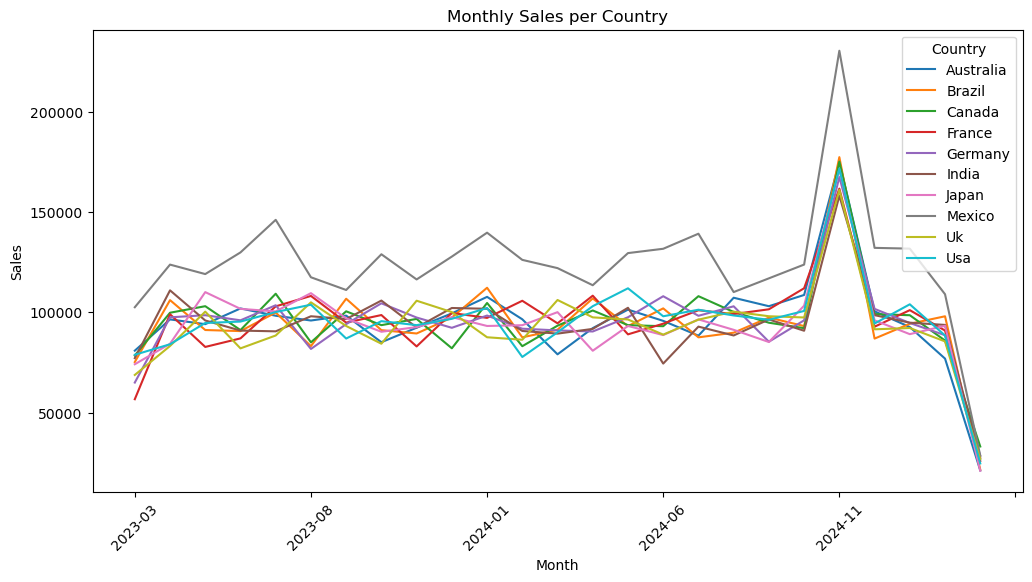

In [26]:
import matplotlib.pyplot as plt

pivot_data.plot(figsize=(12, 6))

plt.title("Monthly Sales per Country")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend(title="Country")
plt.show()

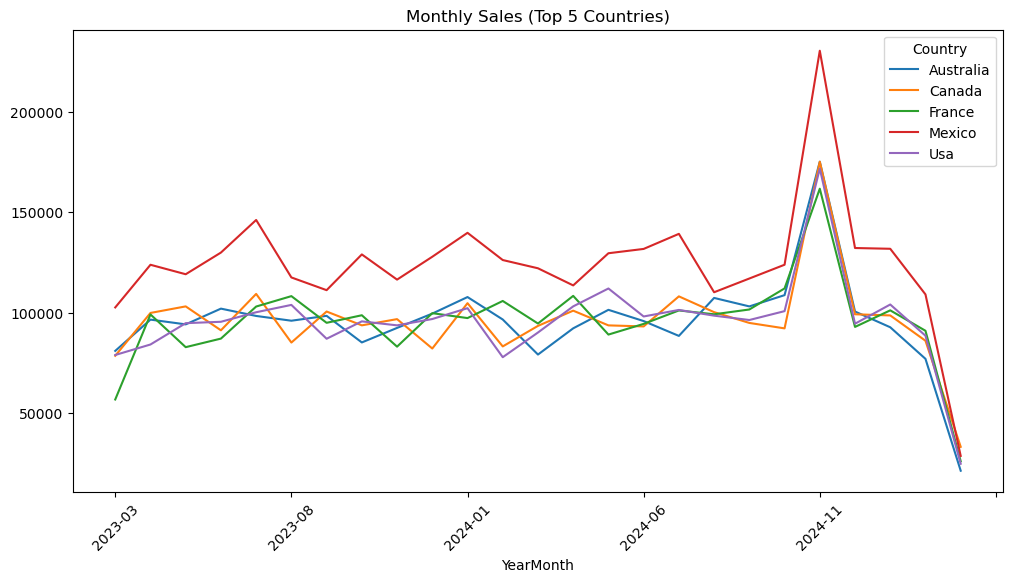

In [27]:
top_countries = df.groupby('Country')['Purchase_Amount'].sum().nlargest(5).index

filtered = monthly_country_sales[
    monthly_country_sales['Country'].isin(top_countries)
]

pivot_data = filtered.pivot(
    index='YearMonth',
    columns='Country',
    values='Purchase_Amount'
)

pivot_data.plot(figsize=(12, 6))
plt.title("Monthly Sales (Top 5 Countries)")
plt.xticks(rotation=45)
plt.show()

In [21]:
country_payment = (
    df.groupby(['Country', 'Payment_Method'])
      .size()
      .reset_index(name='Count')
)

# Get most used payment method per country
result = country_payment.loc[
    country_payment.groupby('Country')['Count'].idxmax()
]

print(result)

      Country Payment_Method  Count
5   Australia            Upi    921
11     Brazil            Upi    915
17     Canada            Upi    964
23     France            Upi    910
29    Germany            Upi    918
35      India            Upi    929
41      Japan            Upi    853
47     Mexico            Upi   1161
53         Uk            Upi    894
59        Usa            Upi    944


Payment_Method
Upi                 9409
Cash On Delivery    7977
Credit Card         7872
Debit Card          7853
Paypal              7748
Net Banking         7713
Name: count, dtype: int64


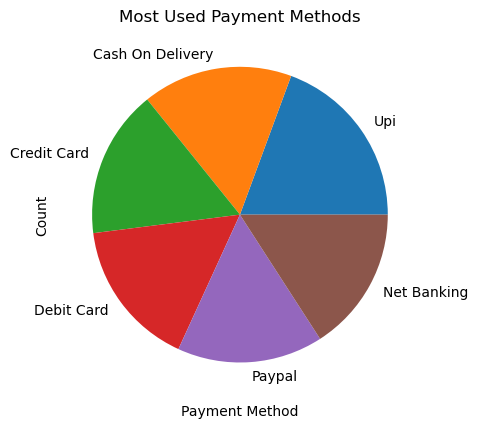

In [31]:
import matplotlib.pyplot as plt

paymentsmethods=df['Payment_Method'].value_counts()
print(paymentsmethods)
paymentsmethods.plot(kind='pie')
plt.title("Most Used Payment Methods")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.show()

In [18]:
#Top 10 customers who spend the most money in the business#

Top_Customers = df.groupby('Customer_ID')['Purchase_Amount'].sum().sort_values(ascending=False).head(10)
print(Top_Customers)

Customer_ID
47133    999.98
41015    999.98
36985    999.95
19236    999.94
20014    999.93
39680    999.89
24800    999.89
28851    999.89
8135     999.87
13436    999.87
Name: Purchase_Amount, dtype: float64


In [19]:
#Top Category = Most sold type of product#

print("Top Category:", df.groupby('Product_Category')['Purchase_Amount'].sum().idxmax())

#Top Country = Country giving most revenue#

print("Top Country:", df.groupby('Country')['Purchase_Amount'].sum().idxmax())

#Best Customer = Customer who spends the most#

print("Best Customer:", df.groupby('Customer_ID')['Purchase_Amount'].sum().idxmax())

Top Category: Toys
Top Country: Mexico
Best Customer: 41015


In [20]:
df.to_csv('cleaned_data.csv', index=False)